In [8]:
!pip install -q diffusers transformers accelerate safetensors

In [9]:
# Step 2: Load the Stable Diffusion model

import torch
from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

print("Stable Diffusion model loaded successfully!")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Stable Diffusion model loaded successfully!


In [10]:
# Step 3: Generate an image from a text prompt

prompt = "A futuristic city at sunset, with flying cars, tall glass buildings, neon lights, and a beautiful sky"

print("Prompt:")
print(prompt)

Prompt:
A futuristic city at sunset, with flying cars, tall glass buildings, neon lights, and a beautiful sky


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

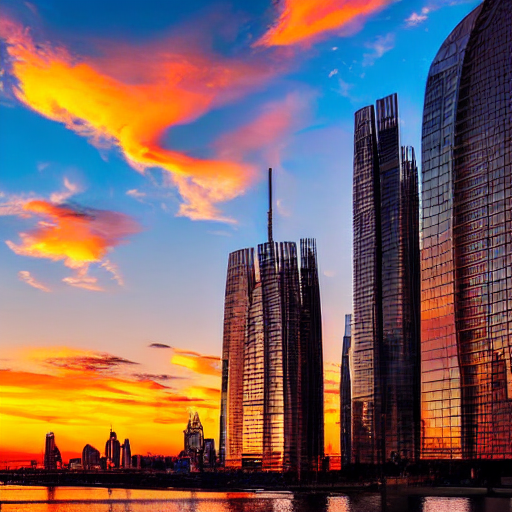

In [11]:
# Step 4: Generate the image

from diffusers import StableDiffusionPipeline
import torch

model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

image = pipe(prompt, num_inference_steps=30).images[0]

display(image)

In [12]:
# Step 5: Save the generated image

image_path = "generated_image.png"
image.save(image_path)

print("Image saved successfully as:", image_path)

Image saved successfully as: generated_image.png


In [13]:
# Step 6: Generate images from multiple text prompts

prompts = [
    "A futuristic city at sunset, with flying cars, tall glass buildings, neon lights, and a beautiful sky",

    "A peaceful mountain landscape with a crystal-clear lake, green forests, snow-covered peaks, and a dramatic sky",

    "A cute robot exploring a colorful futuristic garden, surrounded by flowers and glowing plants"
]

generated_images = []

for i, prompt_text in enumerate(prompts, start=1):
    print(f"Generating image {i}...")

    result = pipe(
        prompt_text,
        num_inference_steps=30
    )

    generated_image = result.images[0]
    generated_images.append(generated_image)

    file_name = f"generated_image_{i}.png"
    generated_image.save(file_name)

    print(f"Saved: {file_name}")

print("\nAll images generated successfully!")

Generating image 1...


  0%|          | 0/30 [00:00<?, ?it/s]

Saved: generated_image_1.png
Generating image 2...


  0%|          | 0/30 [00:00<?, ?it/s]

Saved: generated_image_2.png
Generating image 3...


  0%|          | 0/30 [00:00<?, ?it/s]

Saved: generated_image_3.png

All images generated successfully!


Image 1


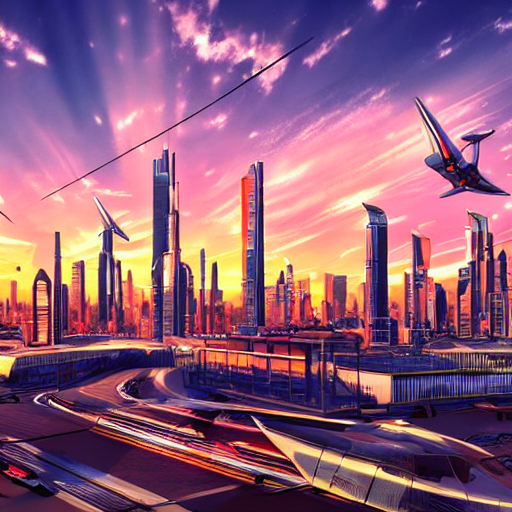

Image 2


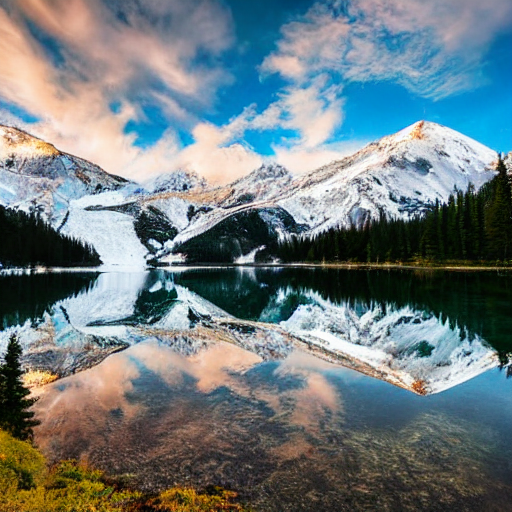

Image 3


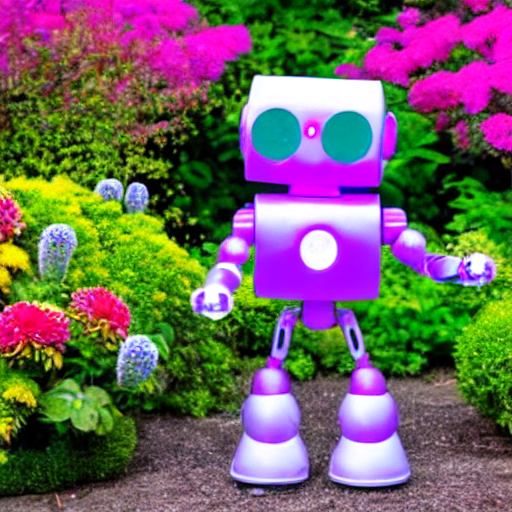

In [14]:
# Step 7: Display the generated images

from IPython.display import display

for i, generated_image in enumerate(generated_images, start=1):
    print(f"Image {i}")
    display(generated_image)